## **Task 1: Data Loading & Exploratory Data Analysis (EDA)**

#### Load the dataset 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset/Mall_Customers.csv')

#### Rename and drop columns 

In [3]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
df.drop(columns=['CustomerID'],inplace=True)

In [5]:
df.rename(columns={'Annual Income (k$)':'AnnualIncome','Spending Score (1-100)':'SpendingScore'},inplace=True)

In [6]:
df.describe()

,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


---

Numerical Data doesn't Contain Outliers by looking at Statstic of Data. 

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         200 non-null    object
 1   Age            200 non-null    int64 
 2   AnnualIncome   200 non-null    int64 
 3   SpendingScore  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


---

DataSet Contains **3** Numerical columns and **1** Categorical Column so We will Apply Label Encoding in Categorical Column and Feature Scaling in Numerical Columns.

---

In [8]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

---

We Nearly have 60-40 split in Customer Based on Gender

---

#### Univariate distributions 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set_style('whitegrid')

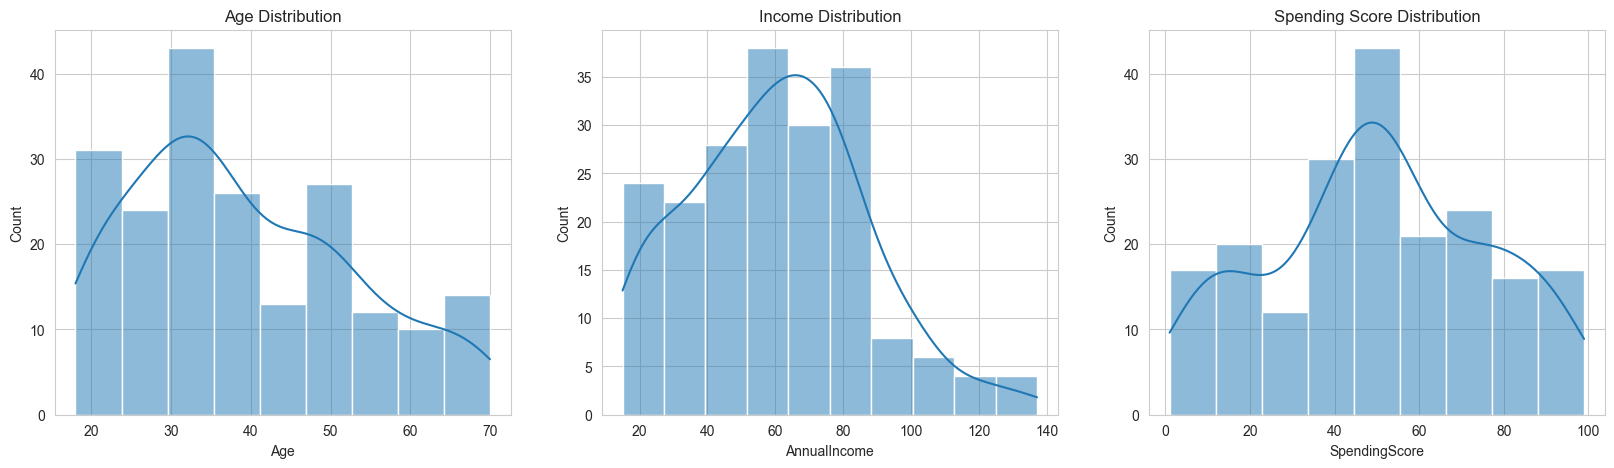

In [11]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.histplot(data=df,x='Age',ax=ax[0],kde=True)
ax[0].set_title('Age Distribution')

sns.histplot(data=df,x='AnnualIncome',ax=ax[1],kde=True)
ax[1].set_title('Income Distribution')

sns.histplot(data=df,x='SpendingScore',ax=ax[2],kde=True)
ax[2].set_title('Spending Score Distribution')

plt.show()

---

**Key Takeaways from the Plots:**

* **Age**: The customer base peaks around the 30–35 age range. It's a bit right-skewed, trailing off as age increases up to 70, with a decent spike in younger customers (around 18–20).

* **Annual Income**: This follows a fairly normal distribution but is slightly right-skewed. The bulk of your customers earn between 40k and 80k, with a few high earners stretching out past 100k up to nearly 140k.

* **Spending Score**: This shows a clear, massive peak right in the middle around 40–50. The rest of the distribution is relatively uniform across the lower and higher scores.

---

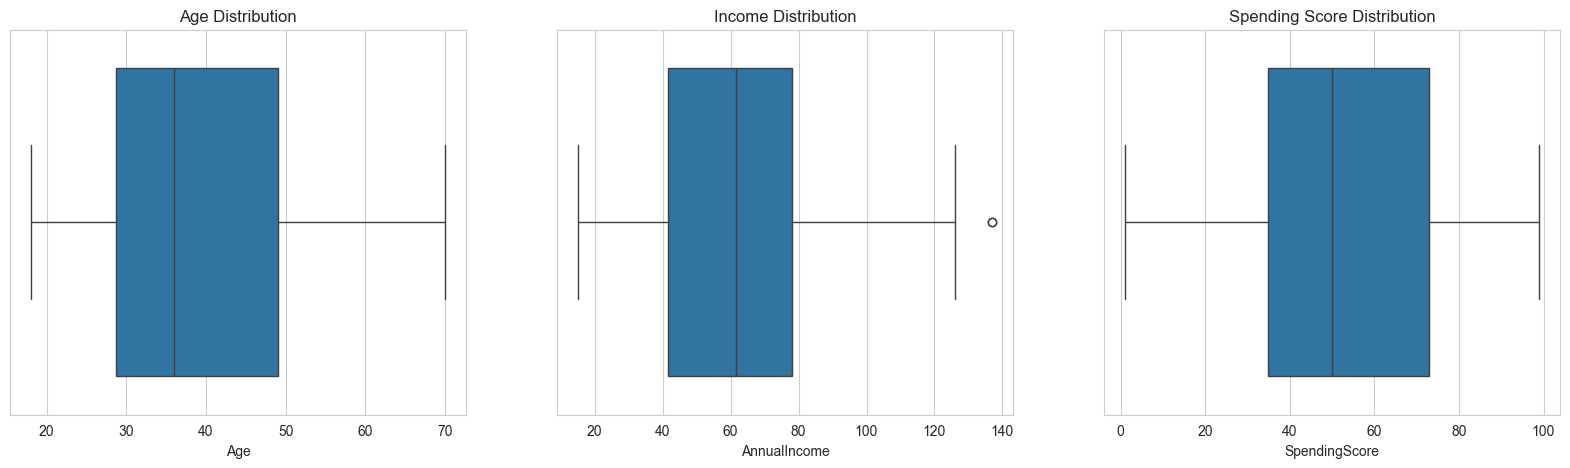

In [12]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.boxplot(data=df,x='Age',ax=ax[0])
ax[0].set_title('Age Distribution')

sns.boxplot(data=df,x='AnnualIncome',ax=ax[1])
ax[1].set_title('Income Distribution')

sns.boxplot(data=df,x='SpendingScore',ax=ax[2])
ax[2].set_title('Spending Score Distribution')

plt.show()

**1. Age Distribution**
* Summary: Represents customers aged between 18 and 70 years old.

* Key Finding: The median age is around 36, with the core 50% of customers (Interquartile Range) falling between 29 and 49. The distribution is fairly balanced with no outliers.

**2. Income Distribution**
* Summary: Shows annual income ranging from approximately $15k to $137k.

* Key Finding: The median income is around $60k–$62k, with most customers earning between $41k and $78k. There is 1 high-income outlier near $137k.

**3. Spending Score Distribution**
* Summary: Covers spending scores spanning almost the full 1 to 100 range (approx. 1 to 99).

* Key Finding: The median score sits right at 50, with the middle 50% of shoppers scoring between 35 and 73. The spread is highly symmetric with no extreme outliers.

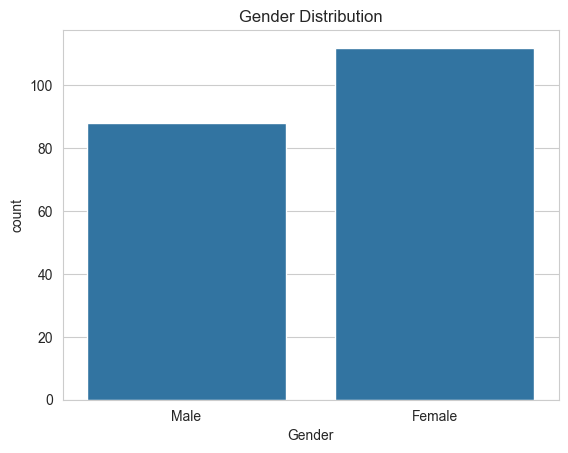

In [13]:
sns.countplot(data=df,x='Gender')
plt.title('Gender Distribution')

plt.show()

---
##### **Is the dataset balanced by gender?** 

Yes, Dataset is balanced by gender because there is not big difference in distribution (like 60-40).

---

#### Bivariate Analysis 

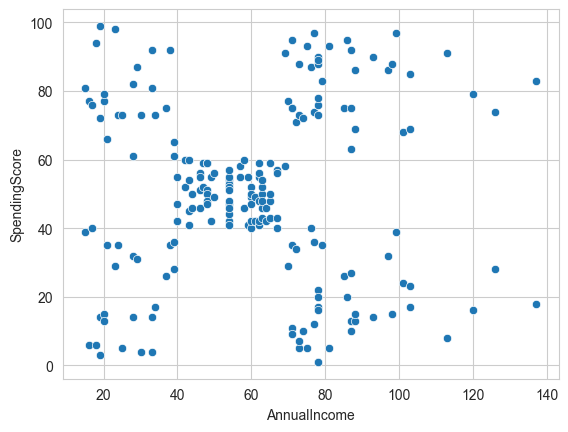

In [14]:
sns.scatterplot(data=df,x='AnnualIncome',y='SpendingScore')
plt.title('')

plt.show()

We can see that there are some data points which are dense in some areas, they we be most likely to form cluters.

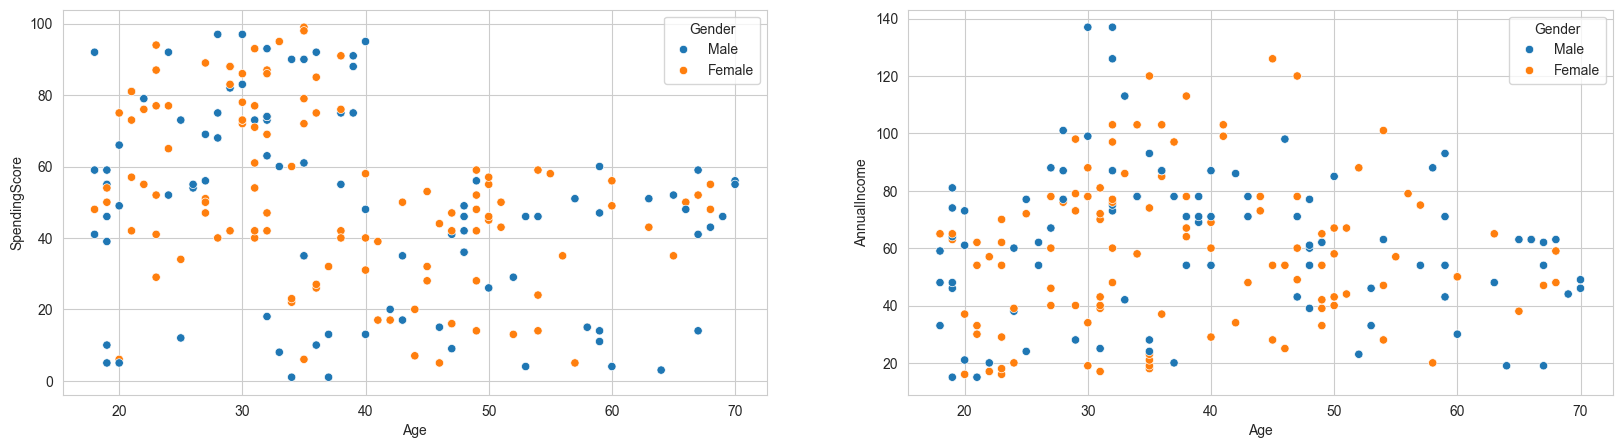

In [15]:
_,ax = plt.subplots(1,2,figsize=(20,5))

sns.scatterplot(data=df,x='Age',y='SpendingScore',hue='Gender',ax=ax[0])
ax[0].set_title('')

sns.scatterplot(data=df,x='Age',y='AnnualIncome',hue='Gender',ax=ax[1])
ax[1].set_title('')

plt.show()

There is no natural grouping by gender by seeing these charts.

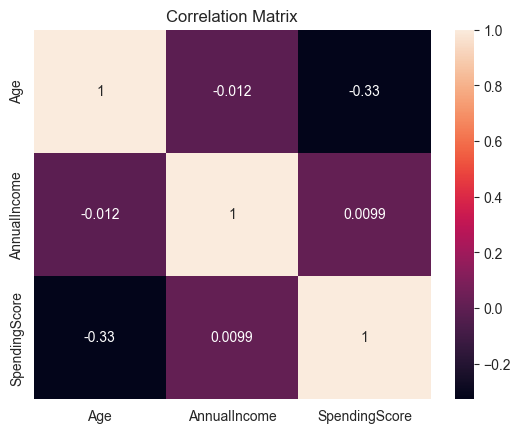

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation Matrix')

plt.show()

---
Strongest Relationship (Age vs. Spending_Score): This pair has the strongest correlation in the dataset at  
−
0.33
 . The negative value indicates that as a customer's age increases, their spending score tends to decrease, hinting at a natural split between younger, higher-spending customers and older, more conservative spenders.
 
 ---

####  Gender-Wise Summary 

In [17]:
grouped_data = df.groupby('Gender')[['Age','AnnualIncome','SpendingScore']].mean()
grouped_data

,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


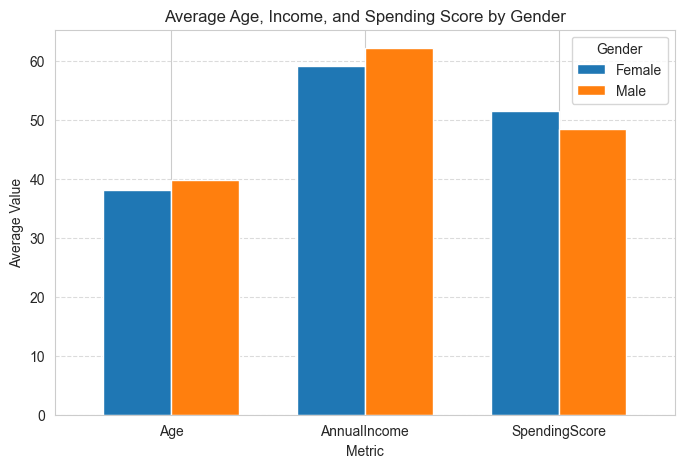

In [18]:
# Transpose the df for visualization

ax = grouped_data.T.plot(kind="bar", figsize=(8, 5), width=0.7)

plt.title("Average Age, Income, and Spending Score by Gender")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)  
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## **Task 2: Feature Scaling & Feature Selection**

#### Encode Gender 

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender_enc'] = le.fit_transform(df['Gender'])

---

By Default 0 was Assigned to Female and 1 was Assigned to Male because of Alphabetical Order.

---

####  Engineer New Features 

In [20]:
income_group_names = ["Low", "Medium", "High"]

In [21]:
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'],q=3,labels=income_group_names)

df['IncomeGroup'].value_counts()

IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

We use qcut so data distribution is nearly same.

In [22]:
age_custom_bins = [18, 25, 40, 55, 70]
age_custom_labels = ["Young", "Adult", "Middle Aged", "Senior"]

In [23]:
df['AgeGroup'] = pd.cut(
    df["Age"], 
    bins=age_custom_bins, 
    labels=age_custom_labels
)

df['AgeGroup'].value_counts()

AgeGroup
Adult          84
Middle Aged    49
Young          34
Senior         29
Name: count, dtype: int64

We Mostly have adult customer (nearly 40%) compare to others.

In [24]:
score_custom_bins = [0,33,66,100]
score_custom_labels = ["Low", "Medium", "High"]

In [25]:
df['SpendingCategory'] = pd.cut(
    df["SpendingScore"], 
    bins=score_custom_bins, 
    labels=score_custom_labels
)

df['SpendingCategory'].value_counts()

SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64

Nearly 50% Customer's SpendingScore is between 33 to 66. but we also many have Customers with high SpeningScore so we can see them as VIPs.

In [26]:
# Income and Score Columns only
X_2d = df[['AnnualIncome','SpendingScore']]

In [27]:
X_5d =  df[['Age', 'AnnualIncome', 'SpendingScore', 'Gender_enc']] 

#### Scale features 

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler_2d = StandardScaler()
scaler_5d = StandardScaler()

In [30]:
# Scaling values into new df 

X_2d_scaled = pd.DataFrame(scaler_2d.fit_transform(X_2d),columns=X_2d.columns)
X_5d_scaled = pd.DataFrame(scaler_5d.fit_transform(X_5d),columns=X_5d.columns)

In [31]:
print(f'Mean: \n{X_2d_scaled.mean().round(2)}')
print()
print(f'Std: \n{X_2d_scaled.std().round(2)}')

Mean: 
AnnualIncome    -0.0
SpendingScore   -0.0
dtype: float64

Std: 
AnnualIncome     1.0
SpendingScore    1.0
dtype: float64


In [32]:
print(f'Mean: \n{X_5d_scaled.mean().round(2)}')
print()
print(f'Std: \n{X_5d_scaled.std().round(2)}')

Mean: 
Age             -0.0
AnnualIncome    -0.0
SpendingScore   -0.0
Gender_enc       0.0
dtype: float64

Std: 
Age              1.0
AnnualIncome     1.0
SpendingScore    1.0
Gender_enc       1.0
dtype: float64


## **Task 3: K-Means Clustering**

#### Elbow Method 

In [33]:
from sklearn.cluster import KMeans

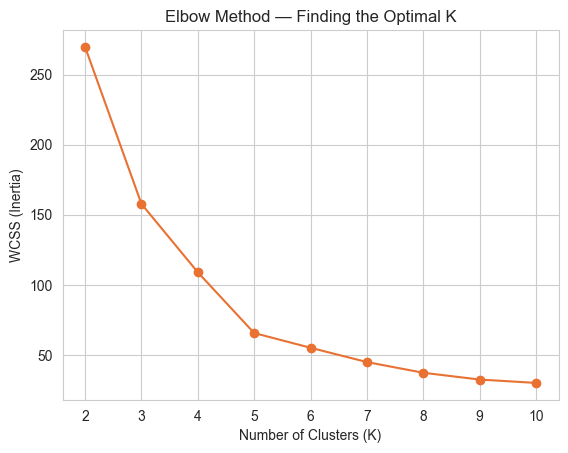

K = 2  ->  WCSS = 269.7
K = 3  ->  WCSS = 157.7
K = 4  ->  WCSS = 108.9
K = 5  ->  WCSS = 65.6
K = 6  ->  WCSS = 55.1
K = 7  ->  WCSS = 44.9
K = 8  ->  WCSS = 37.2
K = 9  ->  WCSS = 32.4
K = 10  ->  WCSS = 30.0


In [34]:
wcss = []
k_ranges = range(2, 11)

for k in k_ranges:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    wcss.append(km.inertia_)

plt.plot(list(k_ranges), wcss, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method \u2014 Finding the Optimal K")
plt.xticks(list(k_ranges))
plt.show()

for k, w in zip(k_ranges, wcss):
    print(f"K = {k}  ->  WCSS = {w:,.1f}")

#### Silhouette Score

In [35]:
from sklearn.metrics import silhouette_score

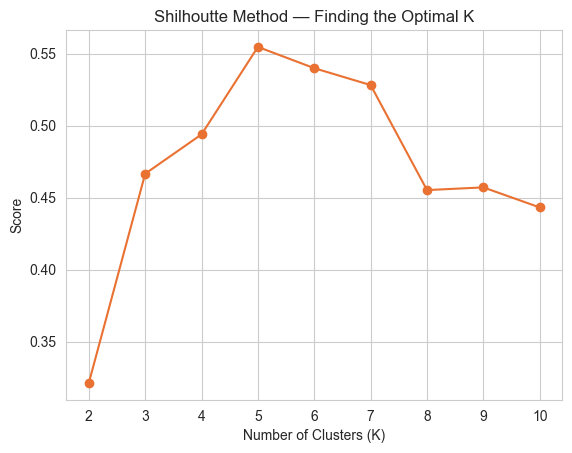

K = 2  ->  WCSS = 0.32
K = 3  ->  WCSS = 0.47
K = 4  ->  WCSS = 0.49
K = 5  ->  WCSS = 0.55
K = 6  ->  WCSS = 0.54
K = 7  ->  WCSS = 0.53
K = 8  ->  WCSS = 0.46
K = 9  ->  WCSS = 0.46
K = 10  ->  WCSS = 0.44


In [36]:
sils = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sils.append(silhouette_score(X_2d_scaled, km.fit(X_2d_scaled).labels_))

plt.plot(list(k_range), sils, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.title("Shilhoutte Method \u2014 Finding the Optimal K")
plt.xticks(list(k_range))
plt.show()

for k, w in zip(k_range, sils):
    print(f"K = {k}  ->  WCSS = {w:,.2f}")

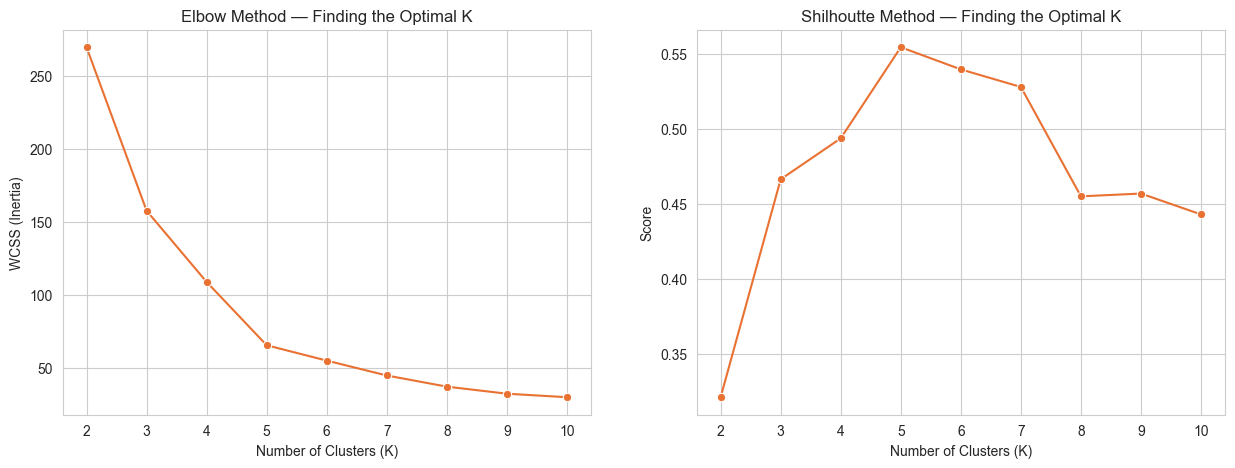

In [37]:
_,axes = plt.subplots(1,2,figsize=(15,5))

sns.lineplot(x=list(k_ranges), y=wcss, marker="o", color="#E97132",ax=axes[0])
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method \u2014 Finding the Optimal K")

sns.lineplot(x=list(k_range), y=sils, marker="o", color="#E97132",ax=axes[1])
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")
axes[1].set_title("Shilhoutte Method \u2014 Finding the Optimal K")

plt.show()

#### Fit final K-Means model

In [38]:
km = KMeans(n_clusters=5, n_init=20, max_iter=500, random_state=42)

In [39]:
df['KMeans_Cluster'] = km.fit_predict(X_2d_scaled)

In [40]:
km_5d = KMeans(n_clusters=5, n_init=20, max_iter=500, random_state=42)

In [41]:
df['KMeans_5D_Cluster'] = km_5d.fit_predict(X_5d_scaled)

In [42]:
silhouette_score(X_2d_scaled, km.labels_)

0.5546571631111091

In [43]:
silhouette_score(X_5d_scaled, km_5d.labels_)

0.31437614343154285

#### Visualise K-Means clusters

In [44]:
centroids = scaler_2d.inverse_transform(km.cluster_centers_)

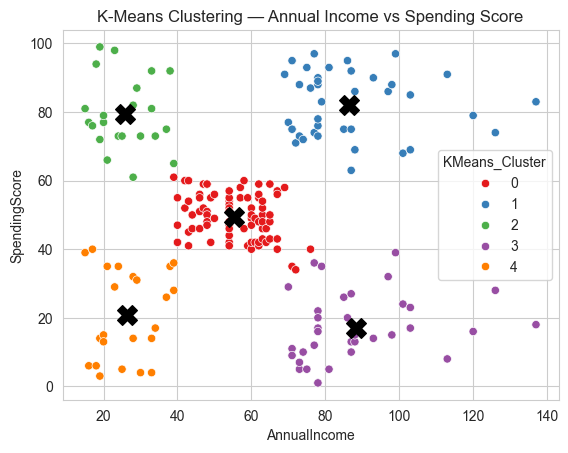

In [45]:
sns.scatterplot(x='AnnualIncome', y='SpendingScore', hue='KMeans_Cluster', data=df, palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200)
plt.title('K-Means Clustering — Annual Income vs Spending Score')

plt.show()

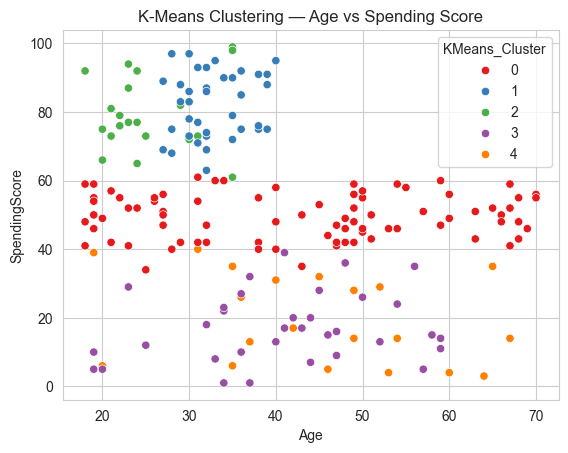

In [46]:
sns.scatterplot(x='Age', y='SpendingScore', hue='KMeans_Cluster', data=df, palette='Set1')
plt.title('K-Means Clustering — Age vs Spending Score')

plt.show()

In [47]:
from sklearn.decomposition import PCA

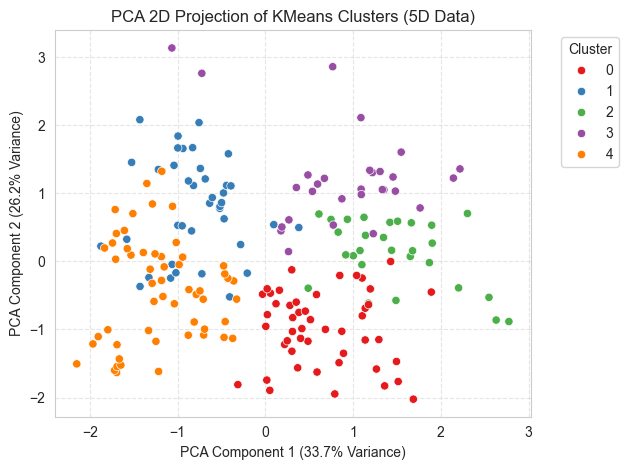

In [48]:
pca_2d = PCA(n_components=2)

pca_result = pca_2d.fit_transform(X_5d_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]



sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="KMeans_5D_Cluster",
    data=df,
    palette="Set1",  
)

# Label axes with explained variance ratios
var_1 = pca_2d.explained_variance_ratio_[0] * 100
var_2 = pca_2d.explained_variance_ratio_[1] * 100

plt.title("PCA 2D Projection of KMeans Clusters (5D Data)")
plt.xlabel(f"PCA Component 1 ({var_1:.1f}% Variance)")
plt.ylabel(f"PCA Component 2 ({var_2:.1f}% Variance)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Profile the K-Means Clusters

In [49]:
df.groupby('KMeans_Cluster')[['Age','AnnualIncome','SpendingScore']].mean().sort_values(by="SpendingScore", ascending=False)

,Age,AnnualIncome,SpendingScore
KMeans_Cluster,,,
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
0,42.716049,55.296296,49.518519
4,45.217391,26.304348,20.913043
3,41.114286,88.200000,17.114286


In [50]:
df.groupby('Gender')['KMeans_Cluster'].value_counts()/len(df) * 100

Gender  KMeans_Cluster
Female  0                 24.0
        1                 10.5
        3                  8.0
        4                  7.0
        2                  6.5
Male    0                 16.5
        3                  9.5
        1                  9.0
        2                  4.5
        4                  4.5
Name: count, dtype: float64

In [51]:
df.groupby('KMeans_Cluster')[['Age','AnnualIncome','SpendingScore']].mean()

,Age,AnnualIncome,SpendingScore
KMeans_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [52]:
persona_map = {
    0: 'Moderate Shoppers',
    1: 'Big Spenders', 
    2: 'Young Aspirers', 
    3: 'Careful Spenders',
    4: 'Budget Shoppers'
}

df["Persona"] = df["KMeans_Cluster"].map(persona_map)

## Task 4: Agglomerative Hierarchical Clustering 

#### Dendrogram

In [53]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [54]:
import numpy as np

In [55]:
linked = linkage(X_2d_scaled, method='ward')

In [56]:
# adding additional variable for cut line.

distances = linked[:, 2]

gaps = np.diff(distances)
largest_gap_idx = np.argmax(gaps)

cut_height = (distances[largest_gap_idx] + distances[largest_gap_idx + 1]) / 2

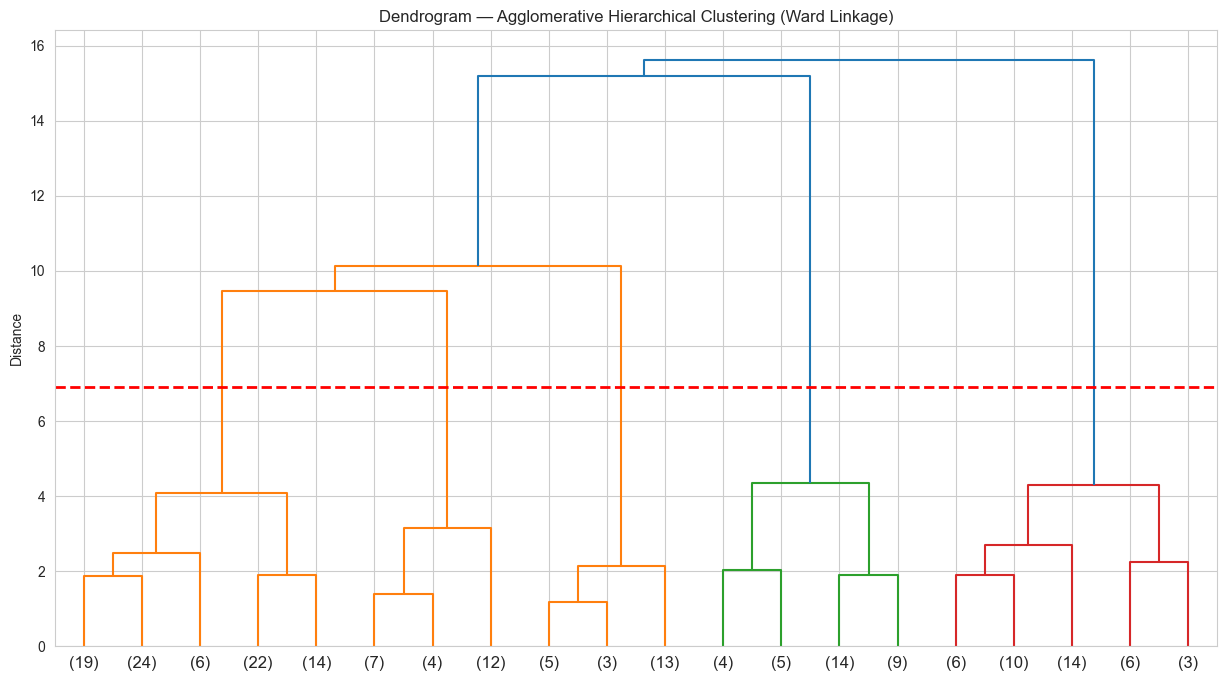

In [57]:
# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=20)
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color="r", linestyle="--", linewidth=2, label=f"Optimal Cut (Height: {cut_height:.2f})")
plt.show()

####  Train Agglomerative Model 

In [58]:
from sklearn.cluster import AgglomerativeClustering

In [59]:
linkage_methods = ["ward", "complete", "average"]

n_clusters = 5

results = []

for linkage in linkage_methods:
    
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)

    
    cluster_labels = model.fit_predict(X_2d_scaled)

    score = silhouette_score(X_2d_scaled, cluster_labels)

    results.append({"Linkage Method": linkage.capitalize(), "Silhouette Score": score})

df_comparison = pd.DataFrame(results)

df_comparison = df_comparison.sort_values(
    by="Silhouette Score", ascending=False
).reset_index(drop=True)

print("=== Hierarchical Clustering Linkage Comparison ===")
df_comparison

=== Hierarchical Clustering Linkage Comparison ===


,Linkage Method,Silhouette Score
0,Ward,0.553809
1,Complete,0.553112
2,Average,0.479426


In [60]:
ward_model = AgglomerativeClustering(n_clusters=5, linkage='ward')

In [61]:
df['Agg_Cluster']= ward_model.fit_predict(X_2d_scaled)

####  Visualise & Profile Hierarchical Clusters 

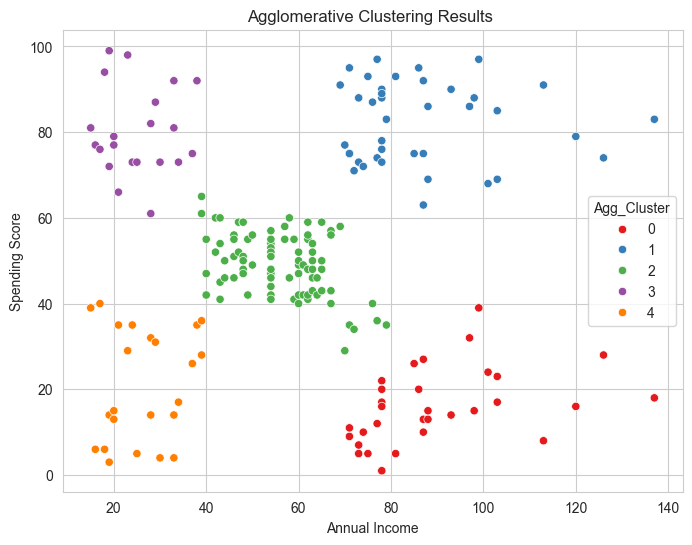

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['AnnualIncome'], y=df['SpendingScore'], hue=df['Agg_Cluster'], palette="Set1")
plt.title('Agglomerative Clustering Results ')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)

plt.show()

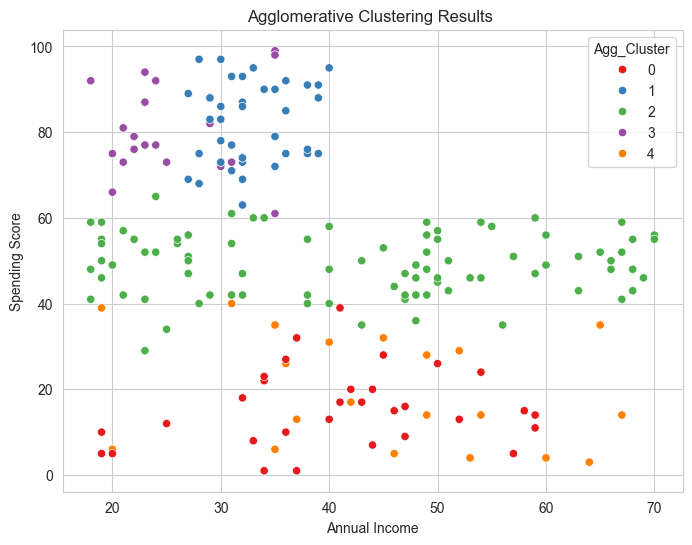

In [63]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Age'], y=df['SpendingScore'], hue=df['Agg_Cluster'], palette="Set1")
plt.title('Agglomerative Clustering Results ')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)

plt.show()

In [64]:
df.groupby('Agg_Cluster')[['Age','AnnualIncome','SpendingScore']].mean()

,Age,AnnualIncome,SpendingScore
Agg_Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


In [65]:
persona_map_agg = {
    2: 'Moderate Shoppers',
    1: 'Big Spenders', 
    3: 'Young Aspirers', 
    0: 'Careful Spenders',
    4: 'Budget Shoppers'
}

df["Persona_Agg"] = df["Agg_Cluster"].map(persona_map_agg)

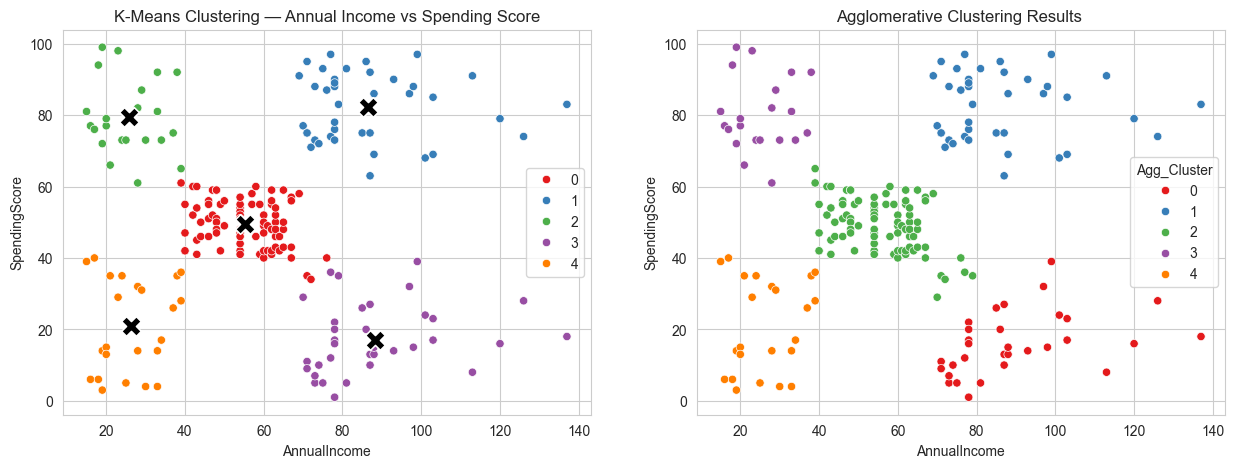

In [66]:
_,ax = plt.subplots(1,2,figsize=(15,5))

sns.scatterplot(x='AnnualIncome', y='SpendingScore', hue='KMeans_Cluster', data=df, palette='Set1',ax=ax[0])
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], c='black', marker='X', s=200,ax=ax[0])
ax[0].set_title('K-Means Clustering — Annual Income vs Spending Score')

sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df, hue=df['Agg_Cluster'], palette='Set1',ax=ax[1])
ax[1].set_title('Agglomerative Clustering Results ')

plt.show()

In [67]:
print(df['Persona'].value_counts()/len(df) * 100,'\n\n',df['Persona_Agg'].value_counts()/len(df) * 100)

Persona
Moderate Shoppers    40.5
Big Spenders         19.5
Careful Spenders     17.5
Budget Shoppers      11.5
Young Aspirers       11.0
Name: count, dtype: float64 

 Persona_Agg
Moderate Shoppers    42.5
Big Spenders         19.5
Careful Spenders     16.0
Budget Shoppers      11.5
Young Aspirers       10.5
Name: count, dtype: float64


## Task 5: DBSCAN Clustering

#### Parameter tuning — epsilon 

In [68]:
from sklearn.neighbors import NearestNeighbors

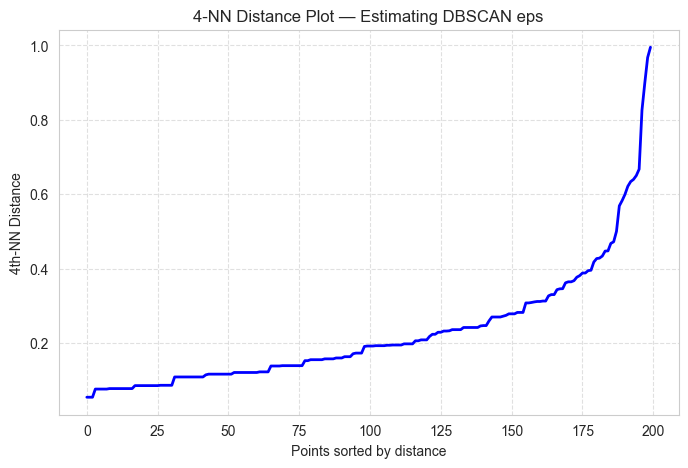

In [80]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_2d_scaled)
distances, indices = neighbors_fit.kneighbors(X_2d_scaled)

#  Sort the distances to the 4th-nearest neighbor (index 3 contains the 4th distance)
sorted_distances = np.sort(distances[:, 3])

#  Plot the sorted k-distances
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances, color='blue', lw=2)
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th-NN Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

The "elbow" occurs around a 4-NN distance of 10 to 12 (between sorted points 175 and 185), where the slope transitions from a steady, gradual rise to a sharp, near-vertical increase. Choosing $\epsilon \approx 10$ ensures that most core density points fall within the cluster neighborhood threshold without merging distant noise points.

---

#### Train DBSCAN Model 

In [72]:
from sklearn.cluster import DBSCAN

In [82]:
dbscan = DBSCAN(eps=0.4, min_samples=4)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d_scaled)

print("DBSCAN Cluster Value Counts:")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Value Counts:
DBSCAN_Cluster
 0    126
 1     33
 2     27
-1     14
Name: count, dtype: int64


There is 3 Clusters Excluding noise. 

In [74]:
print("DBSCAN Cluster Value Counts (%):")
print(df['DBSCAN_Cluster'].value_counts()/len(df) * 100)

DBSCAN Cluster Value Counts (%):
DBSCAN_Cluster
 0    62.5
 1    16.5
 2    13.5
-1     7.5
Name: count, dtype: float64


so our data has 7.5 % noise.

####  Tune DBSCAN Hyperparameters 

In [95]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7,10]

# Initialize list to store results
grid_results = []

#  Iterate through all combinations
for eps in eps_values:
    for min_samples in min_samples_values:
        # Fit DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_2d_scaled)
        
        # Calculate specific metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Calculate silhouette score (excluding noise points per constraints)
        non_noise_mask = labels != -1
        
        # Silhouette score requires at least 2 distinct clusters (excluding noise)
        # and more than 1 point to compute properly
        if n_clusters > 2 and (np.sum(non_noise_mask)/len(df)) >= 0.7:
            score = silhouette_score(X_2d_scaled[non_noise_mask], labels[non_noise_mask])
        else:
            score = np.nan # Not defined if all points are noise or there's only 1 cluster
            
        # Append configurations and metrics
        grid_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Number of Clusters': n_clusters,
            'Noise Points': n_noise,
            'Silhouette Score (Excl. Noise)': round(score, 4) if not np.isnan(score) else np.nan
        })

#  Display results as a clean DataFrame
results_df = pd.DataFrame(grid_results)
results_df

,eps,min_samples,Number of Clusters,Noise Points,Silhouette Score (Excl. Noise)
0,0.2,3,13,44,0.4697
1,0.2,4,5,73,NaN
2,0.2,5,7,77,NaN
3,0.2,7,4,100,NaN
4,0.2,10,1,129,NaN
5,0.3,3,9,14,0.4720
6,0.3,4,8,23,0.5197
7,0.3,5,7,35,0.5243
8,0.3,7,4,72,NaN
9,0.3,10,4,88,NaN


---

* **Objective:** This systematic search tests multiple combinations of `eps` and `min_samples` to map out how different density definitions alter the cluster structures.
* **Evaluation Criteria:** By outputting a comparison table tracking the cluster count, noise points, and noise-excluded silhouette scores, it isolates the precise parameters that deliver the most stable, cohesive segments with minimal unassigned data.
---

In [96]:
heatmap_matrix = results_df.pivot(
    index="eps", columns="min_samples", values='Silhouette Score (Excl. Noise)'
)

<Axes: xlabel='min_samples', ylabel='eps'>

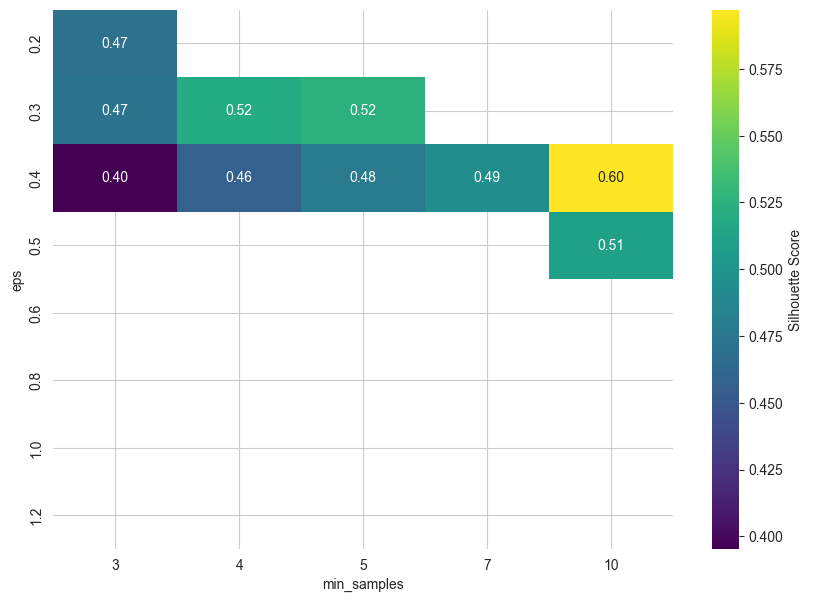

In [97]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Silhouette Score"},
    mask=heatmap_matrix.isna(),  # Optional: leaves invalid (NaN) cells blank
)

#### Fit final DBSCAN model

In [94]:
final_dbscan = DBSCAN(eps=0.4, min_samples=10)

df['DBSCAN_Cluster'] = final_dbscan.fit_predict(X_2d_scaled)

print("DBSCAN Cluster Value Counts:")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Value Counts:
DBSCAN_Cluster
 1    87
-1    51
 2    29
 3    22
 0    11
Name: count, dtype: int64


#### Visualise DBSCAN clusters 

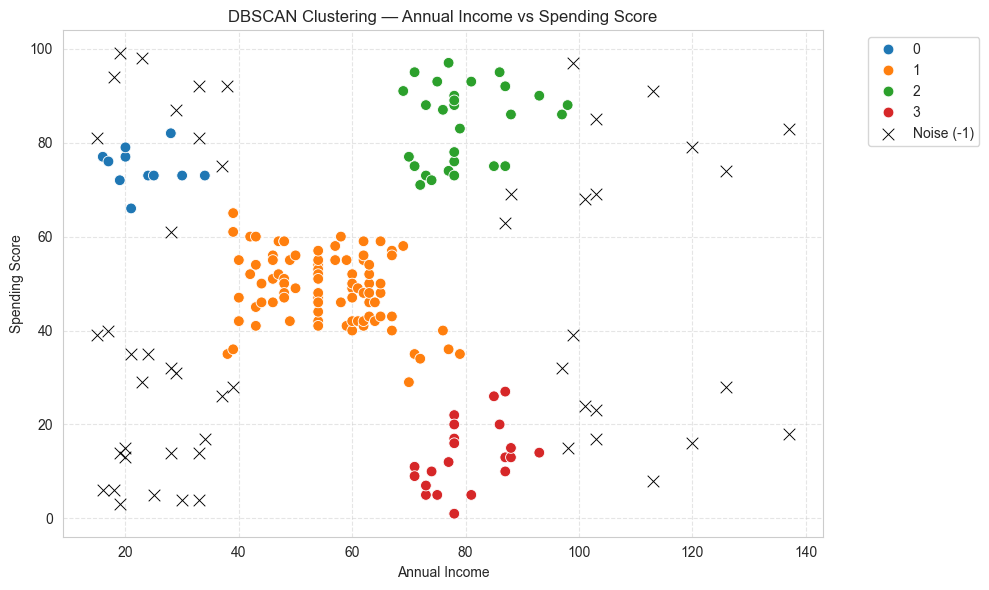

In [100]:
#  Separate core cluster points and noise points
core_points = df[df['DBSCAN_Cluster'] != -1]
noise_points = df[df['DBSCAN_Cluster'] == -1]

plt.figure(figsize=(10, 6))

#  Plot regular clusters using a color palette
sns.scatterplot(
    data=core_points, 
    x='AnnualIncome', 
    y='SpendingScore', 
    hue='DBSCAN_Cluster', 
    palette='tab10', 
    s=60
)

#  Plot noise points explicitly in black with an 'x' marker
sns.scatterplot(
    data=noise_points, 
    x='AnnualIncome', 
    y='SpendingScore', 
    color='black', 
    marker='x', 
    s=70, 
    label='Noise (-1)'
)


plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

##### DBSCAN Core Parameters and Noise Interpretation

* **Epsilon (eps):** Controls the maximum distance radius two points can be from each other to be considered neighbors. It defines the size of the local search neighborhood.
* **Minimum Samples (min_samples):** Controls the minimum number of neighboring points required within the `eps` radius to form a dense core region.
* **Why Noise Points Arise:** Noise points (labeled as -1) are unassigned data points that fail to meet the density criteria. They either do not contain enough neighbors to form their own cluster or fall too far outside the `eps` threshold of any existing dense region.

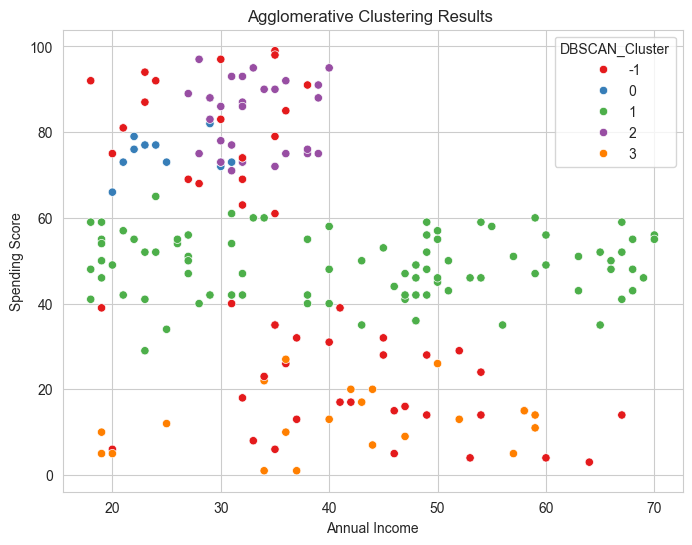

In [101]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Age'], y=df['SpendingScore'], hue=df['DBSCAN_Cluster'], palette="Set1")
plt.title('Agglomerative Clustering Results ')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)

plt.show()

In [105]:
# 1. Group by DBSCAN Cluster and compute mean metrics
dbscan_profile = (
    df.groupby("DBSCAN_Cluster")[["Age", "AnnualIncome", "SpendingScore"]]
    .mean()
    .reset_index()
)

# 2. Separate valid clusters from noise points (-1)
valid_clusters = dbscan_profile[
    dbscan_profile["DBSCAN_Cluster"] != -1
].copy()
noise_profile = dbscan_profile[
    dbscan_profile["DBSCAN_Cluster"] == -1
].copy()

# 3. Map retail personas to valid clusters (Adjust cluster IDs based on your DBSCAN output)
# Example mapping:
persona_map = {
    0: "Young Aspirers",
    1: "Average Shoppers",
    2: "Big Spenders",
    3: "Careful Spenders",
}

valid_clusters["Persona"] = valid_clusters["DBSCAN_Cluster"].map(persona_map)

print("=== Valid DBSCAN Cluster Profiles ===")
print(valid_clusters.to_string(index=False))

print("\n=== DBSCAN Noise Profile ===")
print(noise_profile.to_string(index=False))

=== Valid DBSCAN Cluster Profiles ===
 DBSCAN_Cluster       Age  AnnualIncome  SpendingScore          Persona
              0 25.181818     23.090909      74.636364   Young Aspirers
              1 42.804598     55.413793      48.816092 Average Shoppers
              2 32.931034     79.241379      83.620690     Big Spenders
              3 41.000000     80.181818      12.681818 Careful Spenders

=== DBSCAN Noise Profile ===
 DBSCAN_Cluster       Age  AnnualIncome  SpendingScore
             -1 37.490196     58.333333      44.470588


Noise Shoppers Profile:

The noise points (labeled as cluster -1) represent non-conforming shoppers who do not fall into dense density regions like the core clusters. Rather than simple data entry errors, these shoppers are atypical consumers—such as high earners with moderate spending, or older shoppers with unusually high spending—whose behavior lies in sparse boundary zones between mainstream personas. Consequently, they should be treated as unique niche profiles or edge-case shoppers rather than discarded as pure measurement noise.

## Task 6: Algorithm Comparison & Business Interpretation 

####  Internal Metrics Comparison Table 

In [107]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

In [110]:
# 1. Define models and their final hyperparameters
models = {
    "K-Means": KMeans(n_clusters=5, random_state=42),
    "Hierarchical (Agglomerative)": AgglomerativeClustering(
        n_clusters=5, linkage="ward"
    ),
    "DBSCAN": DBSCAN(eps=0.4, min_samples=10), 
}

table_data = []

# 2. Iterate through models and compute metrics
for name, model in models.items():
    labels = model.fit_predict(X_2d_scaled)

    # Identify noise (-1) vs non-noise points
    is_noise = labels == -1
    noise_pct = (np.sum(is_noise) / len(labels)) * 100

    # Filter out noise points for internal metrics calculation
    non_noise_mask = ~is_noise
    non_noise_X = X_2d_scaled[non_noise_mask]
    non_noise_labels = labels[non_noise_mask]

    # Calculate number of clusters found (excluding noise)
    n_clusters = len(set(non_noise_labels))

    # Compute metrics (requires at least 2 distinct non-noise clusters)
    if n_clusters > 1:
        sil = silhouette_score(non_noise_X, non_noise_labels)
        db = davies_bouldin_score(non_noise_X, non_noise_labels)
        ch = calinski_harabasz_score(non_noise_X, non_noise_labels)
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    # Format hyperparameter string
    if name == "K-Means":
        hyperparams = f"n_clusters={model.n_clusters}"
    elif name == "Hierarchical (Agglomerative)":
        hyperparams = (
            f"n_clusters={model.n_clusters}, linkage='{model.linkage}'"
        )
    elif name == "DBSCAN":
        hyperparams = f"eps={model.eps}, min_samples={model.min_samples}"

    table_data.append(
        {
            "Algorithm": name,
            "Hyperparameters": hyperparams,
            "Clusters Found": n_clusters,
            "Silhouette Score (↑)": round(sil, 4),
            "Davies-Bouldin Index (↓)": round(db, 4),
            "Calinski-Harabasz Index (↑)": round(ch, 2),
            "% Noise Points": f"{noise_pct:.1f}%",
        }
    )

# 3. Create DataFrame
df_metrics = pd.DataFrame(table_data)
df_metrics

=== 6.1 Internal Metrics Comparison Table ===


,Algorithm,Hyperparameters,Clusters Found,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),% Noise Points
0,K-Means,n_clusters=5,5,0.5547,0.5722,248.65,0.0%
1,Hierarchical (Agglomerative),"n_clusters=5, linkage='ward'",5,0.5538,0.5779,244.41,0.0%
2,DBSCAN,"eps=0.4, min_samples=10",4,0.5972,0.4734,263.61,25.5%


##### **Analysis & Summary Write-Up**

Which produced the most well-separated, compact clusters?
* DBSCAN achieved the best scores across all three internal validation metrics:
    * Highest Silhouette Score: $0.5972$ (vs. $0.5547$ for K-Means and $0.5538$ for Hierarchical)
    * Lowest Davies-Bouldin Index: $0.4734$ (vs. $0.5722$ for K-Means)
    * Highest Calinski-Harabasz Index: $263.61$ (vs. $248.65$ for K-Means)

##### **Key Trade-Off** 

The Trade-off: While DBSCAN creates the cleanest, most compact, and well-separated clusters, it leaves $25.5\%$ of the dataset unclassified as noise.
* If the business goal is maximum precision: DBSCAN is preferred because the core clusters it identifies are highly dense and distinct.
* If the business goal is $100\%$ customer coverage: K-Means is the winner, as it assigns every single shopper to one of the 5 retail personas without dropping any data, while maintaining near-optimal cluster metrics.

####  Cluster Stability Check for K-Means 

In [111]:
seeds = [0, 7, 21, 42, 99]
optimal_k = 5  # Using k=5 based on prior analysis

scores = []

# 2. Re-run KMeans for each seed and compute Silhouette Score
for seed in seeds:
    km = KMeans(n_clusters=optimal_k, random_state=seed, n_init=10)
    labels = km.fit_predict(X_2d_scaled)
    score = silhouette_score(X_2d_scaled, labels)
    scores.append({"random_state": seed, "silhouette_score": score})

# 3. Create DataFrame and calculate summary statistics
df_stability = pd.DataFrame(scores)

mean_score = np.mean([s["silhouette_score"] for s in scores])
std_score = np.std([s["silhouette_score"] for s in scores])

print("=== Individual Run Scores ===")
print(df_stability.to_string(index=False))
print(f"\nMean ± Std Dev: {mean_score:.4f} ± {std_score:.4f}")

=== Individual Run Scores ===
 random_state  silhouette_score
            0          0.554657
            7          0.554657
           21          0.554657
           42          0.554657
           99          0.554657

Mean ± Std Dev: 0.5547 ± 0.0000


####  Business Recommendation 